# Forecasting com Modelos Naive (Benchmarks)

**Modelos**: Random Walk (Naive) e Seasonal Naive  
**Séries**: 29 séries econômicas brasileiras (univariadas)  
**Horizonte**: 3 meses  
**Avaliação**: Walk-forward validation (últimos 24 meses como teste)  
**Métricas**: MAE, RMSE, MAPE

---

### Por que benchmarks naive?

Modelos naive são **referências obrigatórias** em qualquer estudo de forecasting (Hyndman & Athanasopoulos, 2021).  
Sem eles, é impossível avaliar se modelos sofisticados realmente agregam valor preditivo.

### Modelos implementados

1. **Random Walk (Naive)**: $\hat{y}_{t+h} = y_t$  
   Previsão = último valor observado. Referência para séries com alta persistência (ex: CPI, M2, Dívida/PIB).

2. **Seasonal Naive**: $\hat{y}_{t+h} = y_{t+h-12}$  
   Previsão = valor do mesmo mês do ano anterior. Referência para séries com padrão sazonal.

### Metodologia

Ambos seguem o **mesmo protocolo walk-forward** dos demais modelos da dissertação:  
- Janelas de 3 meses (HORIZON=3) avançando sobre os 24 meses de teste  
- 8 janelas × 3 meses = 24 previsões por série  
- Multi-step: previsão de h=1,2,3 meses à frente a cada janela  
- MAPE com fórmula epsilon `|y-ŷ|/(y+1e-8)` — padronizada com os demais modelos

---

**Ficha Técnica do Modelo**

| Campo | Valor |
|-------|-------|
| **Modelo** | Random Walk (Naive) e Seasonal Naive |
| **Biblioteca** | NumPy (implementação manual, sem biblioteca de forecasting) |
| **Hiperparâmetros configurados** | `SEASONAL_PERIOD = 12` (fixo) |
| **Busca de hiperparâmetros** | Não |
| **Referência** | Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. OTexts. |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

# Carregar a base de dados com 29 séries econômicas brasileiras (108 meses cada)
df = pd.read_csv('base_economica_brasil.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape} | Período: {df.index.min():%Y-%m} a {df.index.max():%Y-%m}")
print(f"Séries: {len(df.columns)}")

Shape: (108, 29) | Período: 2017-01 a 2025-12
Séries: 29


## 1. Configuração do Experimento

Constantes idênticas aos demais notebooks + funções de previsão naive.

In [2]:
# ============================================================
# Constantes do experimento (idênticas aos demais modelos)
# ============================================================
HORIZON = 3        # Horizonte de previsão: 3 meses à frente
TEST_SIZE = 24     # Período de teste: últimos 24 meses da base
SEASONAL_PERIOD = 12  # Sazonalidade: 12 meses (dados mensais)


def calc_metrics(y_true, y_pred):
    """Calcula MAE, RMSE e MAPE. Usa epsilon 1e-8 para evitar divisão por zero no MAPE."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def naive_forecast(history, horizon):
    """
    Random Walk (Naive): repete o último valor observado para todos os h passos.
    ŷ_{t+h} = y_t  para h = 1, 2, ..., horizon
    """
    return np.full(horizon, history[-1])


def seasonal_naive_forecast(history, horizon, period=12):
    """
    Seasonal Naive: repete os valores do mesmo mês do ano anterior.
    ŷ_{t+h} = y_{t+h-period}
    
    Para h=1: usa o valor de 12 meses atrás do ponto t+1 (= y_{t-11})
    Para h=2: usa o valor de 12 meses atrás do ponto t+2 (= y_{t-10})
    Para h=3: usa o valor de 12 meses atrás do ponto t+3 (= y_{t-9})
    """
    preds = []
    for h in range(1, horizon + 1):
        # Índice no histórico: queremos y_{t+h-period} = history[-(period - h + 1)]
        idx = -(period - h + 1)
        if abs(idx) <= len(history):
            preds.append(history[idx])
        else:
            preds.append(history[-1])  # Fallback para série muito curta
    return np.array(preds)


def classificar(mape):
    """Classifica desempenho por faixa de MAPE (padrão da dissertação)."""
    if mape < 10:
        return '⭐ Excelente'
    elif mape < 20:
        return '✅ Muito Bom'
    elif mape < 30:
        return '👍 Bom'
    elif mape < 50:
        return '⚠️ Regular'
    else:
        return '❌ Difícil'


print(f"Configuração: HORIZON={HORIZON}, TEST_SIZE={TEST_SIZE}, SEASONAL_PERIOD={SEASONAL_PERIOD}")
print(f"Walk-forward: {TEST_SIZE // HORIZON} janelas × {HORIZON} meses = {TEST_SIZE} pontos")

Configuração: HORIZON=3, TEST_SIZE=24, SEASONAL_PERIOD=12
Walk-forward: 8 janelas × 3 meses = 24 pontos


## 2. Treinamento e Previsão (Walk-Forward)

Execução walk-forward para Random Walk e Seasonal Naive em todas as séries.

In [3]:
print("=" * 70)
print("BENCHMARKS NAIVE — Walk-Forward (mesmo protocolo dos demais modelos)")
print("=" * 70)

ALL_SERIES = list(df.columns)
results_naive = []      # Resultados do Random Walk
results_snaive = []     # Resultados do Seasonal Naive

for idx, col in enumerate(ALL_SERIES, 1):
    series = df[col].dropna().values

    if len(series) < TEST_SIZE + SEASONAL_PERIOD:
        print(f"[{idx}/{len(ALL_SERIES)}] {col} — série muito curta, pulando")
        continue

    train_s = series[:-TEST_SIZE]
    test_s = series[-TEST_SIZE:]

    # ── Random Walk ──
    preds_naive, actuals_naive = [], []
    # ── Seasonal Naive ──
    preds_snaive, actuals_snaive = [], []

    for i in range(0, len(test_s), HORIZON):
        n_steps = min(HORIZON, len(test_s) - i)

        # Janela expansível: treino + dados de teste já revelados
        if i == 0:
            history = train_s.copy()
        else:
            history = np.concatenate([train_s, test_s[:i]])

        # Previsões
        rw_preds = naive_forecast(history, n_steps)
        sn_preds = seasonal_naive_forecast(history, n_steps, SEASONAL_PERIOD)

        preds_naive.extend(rw_preds)
        actuals_naive.extend(test_s[i:i + n_steps])
        preds_snaive.extend(sn_preds)
        actuals_snaive.extend(test_s[i:i + n_steps])

    # Métricas
    m_naive = calc_metrics(actuals_naive, preds_naive)
    m_snaive = calc_metrics(actuals_snaive, preds_snaive)

    print(f"[{idx:2}/{len(ALL_SERIES)}] {col:22} | RW  MAPE={m_naive['MAPE']:7.2f}%  | SNaive MAPE={m_snaive['MAPE']:7.2f}%")

    results_naive.append({
        'Serie': col, 'MAE': m_naive['MAE'], 'RMSE': m_naive['RMSE'],
        'MAPE': m_naive['MAPE'], 'N_Pontos': len(preds_naive),
        'preds': np.array(preds_naive), 'actuals': np.array(actuals_naive)
    })
    results_snaive.append({
        'Serie': col, 'MAE': m_snaive['MAE'], 'RMSE': m_snaive['RMSE'],
        'MAPE': m_snaive['MAPE'], 'N_Pontos': len(preds_snaive),
        'preds': np.array(preds_snaive), 'actuals': np.array(actuals_snaive)
    })

print(f"\n{'=' * 70}")
print(f"Concluído: {len(results_naive)} séries processadas com ambos os benchmarks")
print("=" * 70)

BENCHMARKS NAIVE — Walk-Forward (mesmo protocolo dos demais modelos)
[ 1/29] IBC_Br                 | RW  MAPE=   3.18%  | SNaive MAPE=   3.09%
[ 2/29] Selic                  | RW  MAPE=   4.09%  | SNaive MAPE=  22.99%
[ 3/29] Cambio_USDBRL          | RW  MAPE=   4.06%  | SNaive MAPE=   9.22%
[ 4/29] Desemprego             | RW  MAPE=   6.95%  | SNaive MAPE=  16.53%
[ 5/29] Brent_USD              | RW  MAPE=   7.23%  | SNaive MAPE=  13.66%
[ 6/29] Soja_USD               | RW  MAPE=   5.37%  | SNaive MAPE=  19.60%
[ 7/29] Minerio_USD            | RW  MAPE=   5.62%  | SNaive MAPE=  11.50%
[ 8/29] Ibovespa               | RW  MAPE=   4.90%  | SNaive MAPE=  10.57%
[ 9/29] ICC_FGV                | RW  MAPE=   3.18%  | SNaive MAPE=   8.06%
[10/29] Credito_Total          | RW  MAPE=   1.29%  | SNaive MAPE=   8.47%
[11/29] Inadimplencia          | RW  MAPE=   3.86%  | SNaive MAPE=   9.72%
[12/29] Massa_Salarial         | RW  MAPE=   1.14%  | SNaive MAPE=   6.26%
[13/29] CPI_USA                

## 3. Resultados e Métricas

In [4]:
# DataFrames de resultados
df_naive = pd.DataFrame([{k: v for k, v in r.items() if k not in ('preds', 'actuals')}
                         for r in results_naive]).sort_values('MAPE')
df_snaive = pd.DataFrame([{k: v for k, v in r.items() if k not in ('preds', 'actuals')}
                          for r in results_snaive]).sort_values('MAPE')

print("=" * 70)
print("RANDOM WALK (Naive) — Ranking por MAPE")
print("=" * 70)
print(f"\nMAPE médio: {df_naive['MAPE'].mean():.2f}%  |  MAE médio: {df_naive['MAE'].mean():.4f}")
print()
for i, (_, r) in enumerate(df_naive.iterrows(), 1):
    tag = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{tag} {i:2}. {r['Serie']:22} MAPE={r['MAPE']:7.2f}%  MAE={r['MAE']:.4f}")

print(f"\n{'=' * 70}")
print("SEASONAL NAIVE — Ranking por MAPE")
print("=" * 70)
print(f"\nMAPE médio: {df_snaive['MAPE'].mean():.2f}%  |  MAE médio: {df_snaive['MAE'].mean():.4f}")
print()
for i, (_, r) in enumerate(df_snaive.iterrows(), 1):
    tag = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{tag} {i:2}. {r['Serie']:22} MAPE={r['MAPE']:7.2f}%  MAE={r['MAE']:.4f}")

# Comparação: qual naive é melhor por série?
print(f"\n{'=' * 70}")
print("COMPARAÇÃO: Random Walk vs Seasonal Naive")
print("=" * 70)
merged = df_naive[['Serie', 'MAPE']].merge(
    df_snaive[['Serie', 'MAPE']], on='Serie', suffixes=('_RW', '_SNaive'))
merged['Melhor'] = np.where(merged['MAPE_RW'] <= merged['MAPE_SNaive'], 'Random Walk', 'Seasonal Naive')
merged['Diff'] = (merged['MAPE_SNaive'] - merged['MAPE_RW']).round(2)
merged = merged.sort_values('MAPE_RW')

rw_wins = (merged['Melhor'] == 'Random Walk').sum()
sn_wins = (merged['Melhor'] == 'Seasonal Naive').sum()
print(f"\nRandom Walk vence em {rw_wins} séries | Seasonal Naive vence em {sn_wins} séries\n")

for _, r in merged.iterrows():
    marker = '◀ RW' if r['Melhor'] == 'Random Walk' else '▶ SN'
    print(f"  {r['Serie']:22} RW={r['MAPE_RW']:6.2f}%  SN={r['MAPE_SNaive']:6.2f}%  {marker}")

RANDOM WALK (Naive) — Ranking por MAPE

MAPE médio: 6.29%  |  MAE médio: 7404869.9753

🥇  1. Prod_Ind_USA           MAPE=   0.44%  MAE=0.4425
🥈  2. CPI_USA                MAPE=   0.45%  MAE=1.4338
🥉  3. Divida_PIB             MAPE=   0.81%  MAE=0.5067
    4. Massa_Salarial         MAPE=   1.14%  MAE=3968.8750
    5. Credito_Total          MAPE=   1.29%  MAE=48595.1667
    6. M2                     MAPE=   1.60%  MAE=214681471.2917
    7. NUCI_FGV               MAPE=   2.11%  MAE=1.7250
    8. Dollar_Index_Fed       MAPE=   2.12%  MAE=2.6208
    9. ICC_FGV                MAPE=   3.18%  MAE=3.8308
   10. IBC_Br                 MAPE=   3.18%  MAE=3.4651
   11. ETF_Emergentes         MAPE=   3.63%  MAE=1.6398
   12. SP500                  MAPE=   3.66%  MAE=215.1349
   13. Inadimplencia          MAPE=   3.86%  MAE=0.1825
   14. Cambio_USDBRL          MAPE=   4.06%  MAE=0.2299
   15. Selic                  MAPE=   4.09%  MAE=0.5092
   16. PMS_Volume             MAPE=   4.55%  MAE=4.7953
   

## 4. Melhor Naive por Série (Best Naive Benchmark)

Seleciona o melhor modelo (RW ou SNaive) para cada série com base no MAPE.

In [5]:
# Construir tabela de melhor naive por série
best_naive_rows = []
for rw, sn in zip(results_naive, results_snaive):
    serie = rw['Serie']
    if rw['MAPE'] <= sn['MAPE']:
        best = rw.copy()
        best['Modelo_Naive'] = 'Random Walk'
    else:
        best = sn.copy()
        best['Modelo_Naive'] = 'Seasonal Naive'
    best_naive_rows.append(best)

df_best_naive = pd.DataFrame([{k: v for k, v in r.items() if k not in ('preds', 'actuals')}
                              for r in best_naive_rows]).sort_values('MAPE')

print("=" * 70)
print("MELHOR NAIVE POR SÉRIE (benchmark final para comparação)")
print("=" * 70)
print(f"\nMAPE médio (best naive): {df_best_naive['MAPE'].mean():.2f}%\n")

for i, (_, r) in enumerate(df_best_naive.iterrows(), 1):
    modelo_tag = 'RW' if r['Modelo_Naive'] == 'Random Walk' else 'SN'
    print(f"  {i:2}. {r['Serie']:22} MAPE={r['MAPE']:7.2f}%  ({modelo_tag})")

MELHOR NAIVE POR SÉRIE (benchmark final para comparação)

MAPE médio (best naive): 5.83%

   1. Prod_Ind_USA           MAPE=   0.44%  (RW)
   2. CPI_USA                MAPE=   0.45%  (RW)
   3. Divida_PIB             MAPE=   0.81%  (RW)
   4. Massa_Salarial         MAPE=   1.14%  (RW)
   5. Credito_Total          MAPE=   1.29%  (RW)
   6. M2                     MAPE=   1.60%  (RW)
   7. NUCI_FGV               MAPE=   1.64%  (SN)
   8. Dollar_Index_Fed       MAPE=   2.12%  (RW)
   9. ICE_Empresarial        MAPE=   2.50%  (SN)
  10. Vendas_Varejo          MAPE=   2.82%  (SN)
  11. PMS_Volume             MAPE=   2.99%  (SN)
  12. IBC_Br                 MAPE=   3.09%  (SN)
  13. ICC_FGV                MAPE=   3.18%  (RW)
  14. ETF_Emergentes         MAPE=   3.63%  (RW)
  15. SP500                  MAPE=   3.66%  (RW)
  16. Inadimplencia          MAPE=   3.86%  (RW)
  17. Cambio_USDBRL          MAPE=   4.06%  (RW)
  18. Selic                  MAPE=   4.09%  (RW)
  19. Ibovespa              

## 5. Visualização: Ranking MAPE por Série e Real vs. Projetado

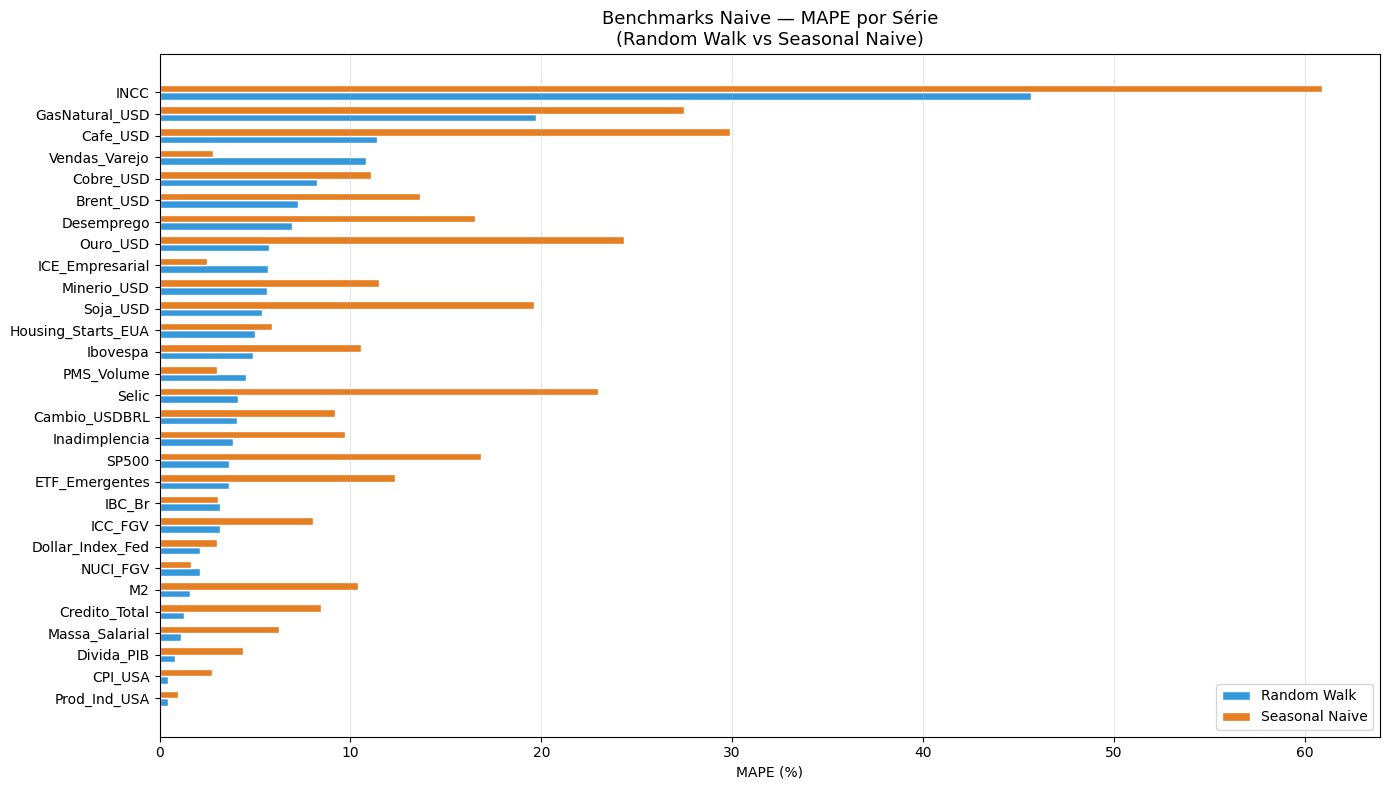

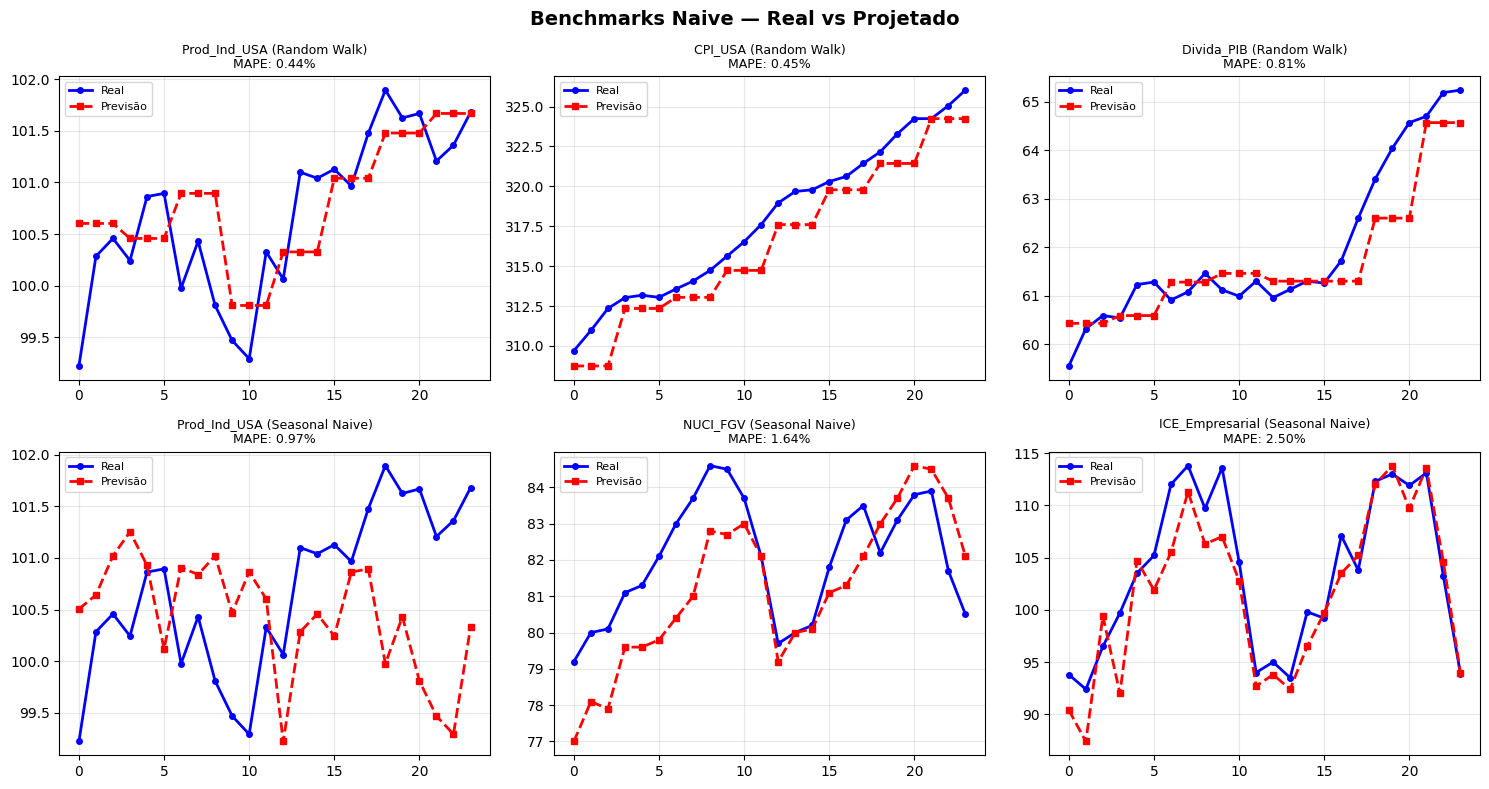

In [6]:
# ============================================================
# Gráfico 1: MAPE por série — RW vs Seasonal Naive (barras agrupadas)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(14, 8))

# Ordenar por MAPE do Random Walk
order = df_naive.sort_values('MAPE')['Serie'].values
df_plot = merged.set_index('Serie').loc[order]

y_pos = np.arange(len(df_plot))
bar_h = 0.35

bars_rw = ax1.barh(y_pos - bar_h/2, df_plot['MAPE_RW'], bar_h,
                   label='Random Walk', color='#3498db', edgecolor='white')
bars_sn = ax1.barh(y_pos + bar_h/2, df_plot['MAPE_SNaive'], bar_h,
                   label='Seasonal Naive', color='#e67e22', edgecolor='white')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_plot.index)
ax1.set_xlabel('MAPE (%)')
ax1.set_title('Benchmarks Naive — MAPE por Série\n(Random Walk vs Seasonal Naive)', fontsize=13)
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)

fig1.tight_layout()
fig1.savefig('naive_mape_por_serie.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Gráfico 2: Real vs Projetado — 3 melhores RW + 3 melhores SNaive
# ============================================================
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top 3 séries onde RW é melhor
top_rw = df_naive.head(3)['Serie'].values
# Top 3 séries onde SNaive é melhor (sorted by SNaive MAPE)
top_sn = df_snaive.head(3)['Serie'].values

series_plot = list(top_rw) + list(top_sn)
titles = ['(Random Walk)'] * 3 + ['(Seasonal Naive)'] * 3
result_lists = [results_naive] * 3 + [results_snaive] * 3

for ax, sn, title_suffix, res_list in zip(axes.flatten(), series_plot, titles, result_lists):
    r = next(x for x in res_list if x['Serie'] == sn)
    ax.plot(r['actuals'], 'b-o', label='Real', ms=4, lw=2)
    ax.plot(r['preds'], 'r--s', label='Previsão', ms=4, lw=2)
    ax.set_title(f"{sn} {title_suffix}\nMAPE: {r['MAPE']:.2f}%", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig2.suptitle('Benchmarks Naive — Real vs Projetado', fontsize=14, fontweight='bold')
fig2.tight_layout()
fig2.savefig('naive_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exportação de Resultados

In [7]:
# ============================================================
# Exportação: Random Walk
# ============================================================
df_save_naive = df_naive.copy()
df_save_naive['Classificacao'] = df_save_naive['MAPE'].apply(classificar)
df_save_naive[['Serie', 'MAE', 'RMSE', 'MAPE', 'N_Pontos', 'Classificacao']].to_csv(
    'resultados_naive.csv', index=False)

# Previsões individuais
prev_rows_naive = []
for r in results_naive:
    serie = r['Serie']
    series_data = df[serie].dropna()
    test_dates = series_data.iloc[-TEST_SIZE:].index
    for d, p in zip(test_dates[:len(r['preds'])], r['preds']):
        prev_rows_naive.append({'Serie': serie, 'Data': str(d)[:10], 'Previsao': p})
pd.DataFrame(prev_rows_naive).to_csv('previsoes_naive.csv', index=False)

# ============================================================
# Exportação: Seasonal Naive
# ============================================================
df_save_snaive = df_snaive.copy()
df_save_snaive['Classificacao'] = df_save_snaive['MAPE'].apply(classificar)
df_save_snaive[['Serie', 'MAE', 'RMSE', 'MAPE', 'N_Pontos', 'Classificacao']].to_csv(
    'resultados_snaive.csv', index=False)

prev_rows_snaive = []
for r in results_snaive:
    serie = r['Serie']
    series_data = df[serie].dropna()
    test_dates = series_data.iloc[-TEST_SIZE:].index
    for d, p in zip(test_dates[:len(r['preds'])], r['preds']):
        prev_rows_snaive.append({'Serie': serie, 'Data': str(d)[:10], 'Previsao': p})
pd.DataFrame(prev_rows_snaive).to_csv('previsoes_snaive.csv', index=False)

print("=" * 60)
print("EXPORTAÇÃO CONCLUÍDA")
print("=" * 60)
print(f"\n📁 Random Walk:")
print(f"   resultados_naive.csv   ({len(df_save_naive)} séries)")
print(f"   previsoes_naive.csv    ({len(prev_rows_naive)} linhas)")
print(f"\n📁 Seasonal Naive:")
print(f"   resultados_snaive.csv  ({len(df_save_snaive)} séries)")
print(f"   previsoes_snaive.csv   ({len(prev_rows_snaive)} linhas)")

EXPORTAÇÃO CONCLUÍDA

📁 Random Walk:
   resultados_naive.csv   (29 séries)
   previsoes_naive.csv    (696 linhas)

📁 Seasonal Naive:
   resultados_snaive.csv  (29 séries)
   previsoes_snaive.csv   (696 linhas)


## 7. Comparação: Naive vs Modelos da Dissertação

In [ ]:
import os

# Carregar resultados dos modelos sofisticados
# Nota: TEMPO foi removido da comparação por limitação estrutural —
# o modelo requer seq_len=336, mas as séries mensais têm apenas 84-108 pontos,
# causando padding que corrompe RevIN, STL e atenção do GPT-2.
MODEL_FILES = {
    'ARIMA': 'resultados_arima.csv',
    'ARCH': 'resultados_arch.csv',
    'Chronos': 'resultados_chronos.csv',
    'ETS': 'resultados_ets.csv',
    'GARCH': 'resultados_garch.csv',
    'LagLlama': 'resultados_lagllama.csv',
    'Prophet': 'resultados_prophet.csv',
    'RandomForest': 'resultados_randomforest.csv',
    'SARIMAX': 'resultados_sarimax.csv',
    'Theta': 'resultados_theta.csv',
    'TimesFM': 'resultados_timesfm.csv',
    'XGBoost': 'resultados_xgboost.csv',
}

all_models = []
for model_name, filename in MODEL_FILES.items():
    if os.path.exists(filename):
        tmp = pd.read_csv(filename)
        tmp['Modelo'] = model_name
        all_models.append(tmp)

if all_models:
    df_models = pd.concat(all_models, ignore_index=True)
    print(f"Carregados: {len(set(df_models['Modelo']))} modelos")
    print()

    # Criar lookup do melhor naive por série
    naive_lookup = df_best_naive.set_index('Serie')['MAPE'].to_dict()
    naive_model_lookup = df_best_naive.set_index('Serie')['Modelo_Naive'].to_dict()

    # ── Análise 1: Para cada modelo, quantas séries superam o naive? ──
    print("=" * 70)
    print("QUANTAS SÉRIES CADA MODELO SUPERA O MELHOR NAIVE?")
    print("=" * 70)
    print(f"{'Modelo':16} {'Supera':>7} {'Empata':>7} {'Perde':>7}  {'Taxa':>6}")
    print("-" * 50)

    model_scores = []
    for modelo in sorted(df_models['Modelo'].unique()):
        sub = df_models[df_models['Modelo'] == modelo]
        wins, ties, losses = 0, 0, 0
        for _, row in sub.iterrows():
            serie = row['Serie']
            if serie in naive_lookup:
                naive_mape = naive_lookup[serie]
                if row['MAPE'] < naive_mape - 0.01:  # margem de 0.01% para empate
                    wins += 1
                elif row['MAPE'] > naive_mape + 0.01:
                    losses += 1
                else:
                    ties += 1
        total = wins + ties + losses
        taxa = wins / total * 100 if total > 0 else 0
        print(f"  {modelo:14} {wins:7} {ties:7} {losses:7}  {taxa:5.1f}%")
        model_scores.append({'Modelo': modelo, 'Supera_Naive': wins, 'Empata': ties,
                            'Perde_Naive': losses, 'Taxa_Superacao': taxa})

    df_scores = pd.DataFrame(model_scores).sort_values('Taxa_Superacao', ascending=False)

    # ── Análise 2: Para cada série, quantos modelos superam o naive? ──
    print(f"\n{'=' * 70}")
    print("PARA CADA SÉRIE: QUANTOS MODELOS SUPERAM O MELHOR NAIVE?")
    print("=" * 70)

    series_analysis = []
    for serie in ALL_SERIES:
        if serie not in naive_lookup:
            continue
        naive_mape = naive_lookup[serie]
        naive_model = naive_model_lookup[serie]
        sub = df_models[df_models['Serie'] == serie]
        n_supera = (sub['MAPE'] < naive_mape - 0.01).sum()
        n_total = len(sub)

        # Melhor modelo sofisticado
        if len(sub) > 0:
            best_row = sub.loc[sub['MAPE'].idxmin()]
            best_model = best_row['Modelo']
            best_mape = best_row['MAPE']
        else:
            best_model, best_mape = '-', 999

        veredito = '✅' if best_mape < naive_mape else '❌'
        series_analysis.append({
            'Serie': serie, 'Naive_MAPE': naive_mape, 'Naive_Modelo': naive_model,
            'Melhor_Modelo': best_model, 'Melhor_MAPE': best_mape,
            'N_Superam': n_supera, 'N_Total': n_total, 'Supera': veredito
        })

    df_series_analysis = pd.DataFrame(series_analysis).sort_values('Naive_MAPE')

    for _, r in df_series_analysis.iterrows():
        print(f"  {r['Supera']} {r['Serie']:22} Naive({r['Naive_Modelo'][:2]})={r['Naive_MAPE']:6.2f}%  "
              f"Melhor: {r['Melhor_Modelo']:12}={r['Melhor_MAPE']:6.2f}%  "
              f"({r['N_Superam']}/{r['N_Total']} superam)")

    n_series_onde_modelos_vencem = (df_series_analysis['Supera'] == '✅').sum()
    n_total = len(df_series_analysis)
    print(f"\n📊 Resumo: Em {n_series_onde_modelos_vencem}/{n_total} séries, "
          f"pelo menos um modelo sofisticado supera o melhor naive.")
else:
    print("⚠️ Nenhum resultado de modelo encontrado. Execute os notebooks dos modelos primeiro.")

Carregados: 13 modelos

QUANTAS SÉRIES CADA MODELO SUPERA O MELHOR NAIVE?
Modelo            Supera  Empata   Perde    Taxa
--------------------------------------------------
  ARCH                 7      13       9   24.1%
  ARIMA               15       3      11   51.7%
  Chronos             16       0      13   55.2%
  ETS                 13       1      15   44.8%
  GARCH                7      13       9   24.1%
  LagLlama             2       0      27    6.9%
  Prophet              7       0      22   24.1%
  RandomForest        10       0      19   34.5%
  SARIMAX             12       9       8   41.4%
  TEMPO                0       0      29    0.0%
  Theta               11       0      18   37.9%
  TimesFM             12       0      17   41.4%
  XGBoost              3       0      26   10.3%

PARA CADA SÉRIE: QUANTOS MODELOS SUPERAM O MELHOR NAIVE?
  ❌ Prod_Ind_USA           Naive(Ra)=  0.44%  Melhor: SARIMAX     =  0.46%  (0/13 superam)
  ✅ CPI_USA                Naive(Ra)=  0

## 8. Visualização: Taxa de Superação do Naive por Modelo

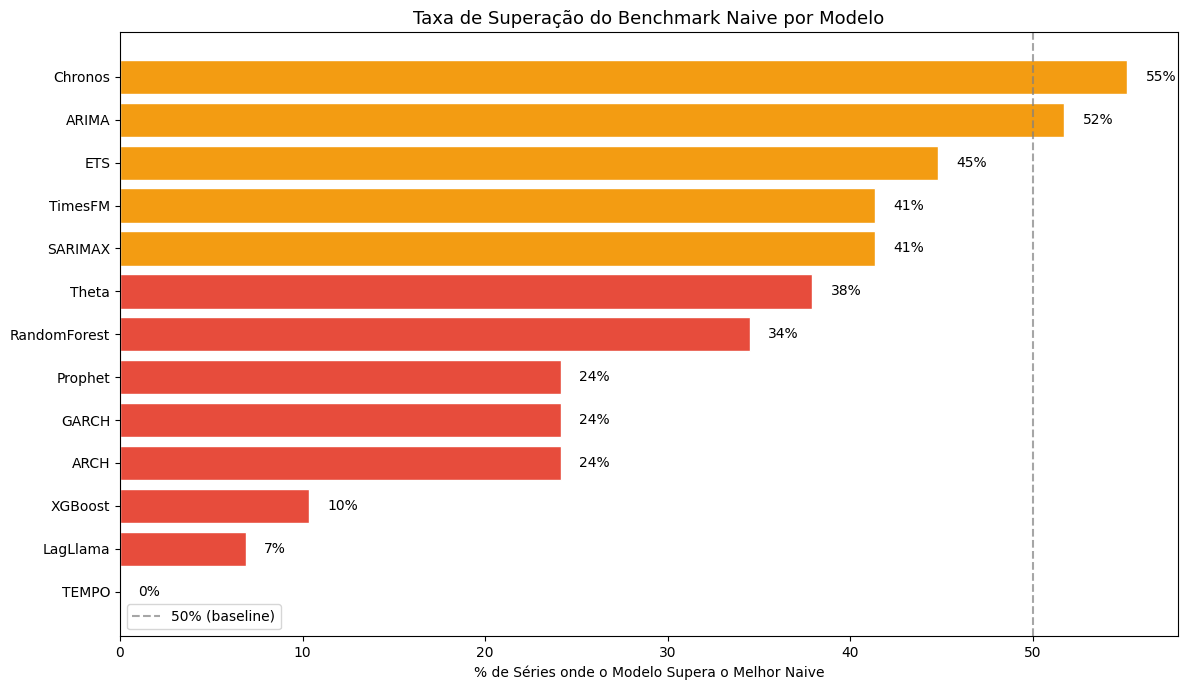

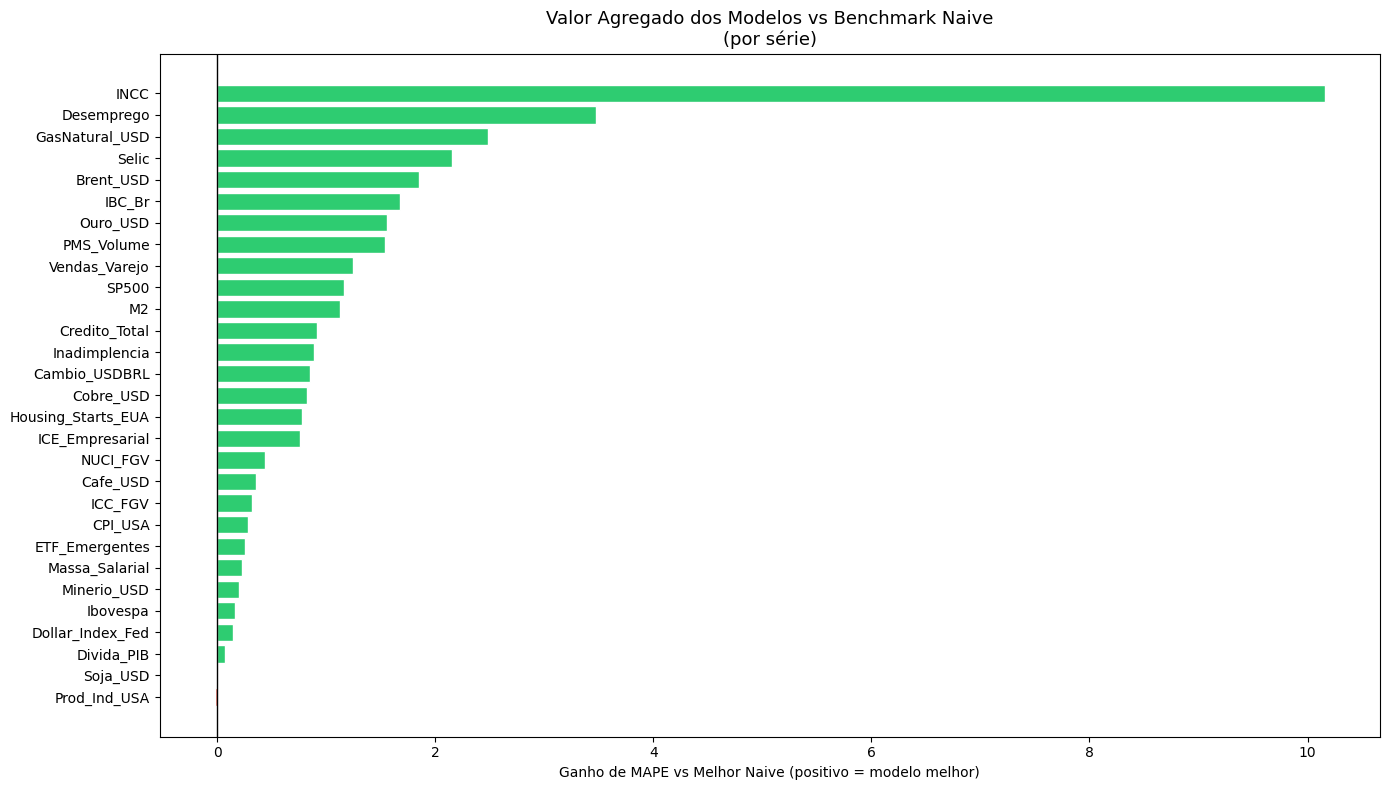

RESUMO FINAL — Benchmarks Naive

Random Walk  — MAPE médio: 6.29%
Seasonal Naive — MAPE médio: 12.41%
Best Naive     — MAPE médio: 5.83%

Melhor modelo geral (média): Chronos (supera naive em 55% das séries)

📊 Séries onde modelos > naive: 27/29
📊 Séries onde naive é imbatível: 2/29


In [9]:
if all_models:
    # ============================================================
    # Gráfico 3: Taxa de superação do naive por modelo
    # ============================================================
    fig3, ax3 = plt.subplots(figsize=(12, 7))

    df_plot3 = df_scores.sort_values('Taxa_Superacao')
    colors = ['#2ecc71' if t >= 60 else '#f39c12' if t >= 40 else '#e74c3c'
              for t in df_plot3['Taxa_Superacao']]

    ax3.barh(df_plot3['Modelo'], df_plot3['Taxa_Superacao'], color=colors, edgecolor='white')
    ax3.axvline(x=50, color='gray', linestyle='--', alpha=0.7, label='50% (baseline)')
    ax3.set_xlabel('% de Séries onde o Modelo Supera o Melhor Naive')
    ax3.set_title('Taxa de Superação do Benchmark Naive por Modelo', fontsize=13)
    ax3.legend()

    # Valores nas barras
    for i, (_, r) in enumerate(df_plot3.iterrows()):
        ax3.text(r['Taxa_Superacao'] + 1, i, f"{r['Taxa_Superacao']:.0f}%",
                 va='center', fontsize=10)

    fig3.tight_layout()
    fig3.savefig('naive_taxa_superacao.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # Gráfico 4: Heatmap — MAPE Naive vs Melhor Modelo por Série
    # ============================================================
    fig4, ax4 = plt.subplots(figsize=(14, 8))

    df_heat = df_series_analysis[['Serie', 'Naive_MAPE', 'Melhor_MAPE']].copy()
    df_heat['Ganho_vs_Naive'] = df_heat['Naive_MAPE'] - df_heat['Melhor_MAPE']
    df_heat = df_heat.sort_values('Ganho_vs_Naive', ascending=True)

    colors4 = ['#2ecc71' if g > 0 else '#e74c3c' for g in df_heat['Ganho_vs_Naive']]
    ax4.barh(df_heat['Serie'], df_heat['Ganho_vs_Naive'], color=colors4, edgecolor='white')
    ax4.axvline(x=0, color='black', linewidth=1)
    ax4.set_xlabel('Ganho de MAPE vs Melhor Naive (positivo = modelo melhor)')
    ax4.set_title('Valor Agregado dos Modelos vs Benchmark Naive\n(por série)', fontsize=13)

    fig4.tight_layout()
    fig4.savefig('naive_ganho_por_serie.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # Resumo final
    # ============================================================
    print("=" * 60)
    print("RESUMO FINAL — Benchmarks Naive")
    print("=" * 60)
    print(f"\nRandom Walk  — MAPE médio: {df_naive['MAPE'].mean():.2f}%")
    print(f"Seasonal Naive — MAPE médio: {df_snaive['MAPE'].mean():.2f}%")
    print(f"Best Naive     — MAPE médio: {df_best_naive['MAPE'].mean():.2f}%")
    print(f"\nMelhor modelo geral (média): {df_scores.iloc[0]['Modelo']} "
          f"(supera naive em {df_scores.iloc[0]['Taxa_Superacao']:.0f}% das séries)")
    print(f"\n📊 Séries onde modelos > naive: {n_series_onde_modelos_vencem}/{n_total}")
    print(f"📊 Séries onde naive é imbatível: {n_total - n_series_onde_modelos_vencem}/{n_total}")